# Notebook 4: Supervised EDA and Feature Selection

**Purpose:** Feature vs. Target analysis and dimensionality reduction.

**Actions:**
- Load the engineered features and labels from Notebook 3.
- **Supervised EDA:** Analyze Feature vs. Target (e.g., *Does a higher `user_item_repurchase_30d` correlate with a label of 1?*).
- **Feature Selection:** Run a correlation matrix to find redundant/collinear features.
- Train a quick baseline Random Forest or XGBoost to check Feature Importance and SHAP values. (Skipped for now, added as TODO)
- Drop features with near-zero variance or no predictive power to finalize the model input schema. (Skipped for now, added as TODO)

*Note: This notebook uses Pandas for data manipulation and analysis.*

## 1. Setup and Imports

In this section, we import the necessary Python libraries for data manipulation and visualization.

In [7]:
import os
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Add notebooks/ to sys.path so utils/ is importable without installing the package
for _nb in (Path.cwd(), Path.cwd() / "notebooks", Path.cwd().parent / "notebooks"):
    if (_nb / "utils").is_dir():
        sys.path[:0] = [str(_nb)]
        break

from utils.data_casting import cast_table, save_parquet_hive

# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 2. Define Data Paths

Next, we define the file paths for the engineered features dataset.

In [8]:
def get_data_paths() -> dict:
    """
    Define and return the paths for the input datasets.
    
    Returns:
        dict: A dictionary containing paths to the input data directories.
    """
    base_dir = "../s3/dataset/sample_2000_users"
    
    paths = {
        "features": os.path.join(base_dir, "features"),
    }
    return paths

data_paths = get_data_paths()

## 3. Load Data

We load the engineered features (which already contain the target `label`) from Parquet files into a Pandas DataFrame.

In [9]:
def load_data(paths: dict) -> pd.DataFrame:
    """
    Load the features data from Parquet files.
    
    Args:
        paths (dict): Dictionary containing data paths.
        
    Returns:
        pd.DataFrame: A DataFrame containing the features and labels.
    """
    print("Loading features...")
    # Note: If pyarrow or fastparquet is missing, this will fail.
    # Ensure you have the required libraries installed.
    df = pd.read_parquet(paths["features"])
    return df

try:
    df = load_data(data_paths)
    print("Data loaded successfully.")
    print(f"Dataset shape: {df.shape}")
except Exception as e:
    print(f"Error loading data: {e}")
    # Creating a dummy dataframe for demonstration purposes if loading fails
    print("Creating a dummy DataFrame for demonstration.")
    np.random.seed(42)
    df = pd.DataFrame({
        'customer_id': np.random.randint(1, 100, 1000),
        'article_id': np.random.randint(1, 50, 1000),
        'label': np.random.choice([0, 1], p=[0.8, 0.2], size=1000),
        'item_pop_30d': np.random.exponential(10, 1000),
        'item_avg_price': np.random.normal(30, 10, 1000),
        'user_item_repurchase_30d': np.random.poisson(0.5, 1000),
        'user_purchase_count_30d': np.random.poisson(2, 1000)
    })

Loading features...
Data loaded successfully.
Dataset shape: (2788, 76)


---

## 3.5. Cast Types and Persist

Apply ML-specific Pandas dtypes defined in `configs/features/ml_types.yaml` to the features DataFrame, then overwrite the Hive Parquet dataset on disk.

**Why:** Spark writes all integers as `int64` and all floats as `float64`. Casting to `Int32`/`float32`/`category` halves memory usage, makes categorical columns explicit, and ensures downstream model code (XGBoost, two-tower) reads correctly-typed data without repeating conversions.

**Output:** `s3/dataset/sample_2000_users/features` overwritten in place with correct dtypes.

In [10]:
def cast_and_persist_features(df: pd.DataFrame, paths: dict) -> pd.DataFrame:
    """
    Cast the features DataFrame to ML-appropriate Pandas dtypes and overwrite the Hive Parquet dataset.

    Dtype definitions come from configs/features/ml_types.yaml (section 'features').
    Only columns present in both the DataFrame and the config are cast; any extra
    columns in either are silently skipped.

    save_parquet_hive() resolves the path relative to the repo root (the directory that
    contains configs/), so paths here use the repo-relative prefix (no '../').

    Args:
        df: Features DataFrame loaded from Parquet.
        paths: Data paths dict from get_data_paths().

    Returns:
        pd.DataFrame: Casted DataFrame (replaces the input).
    """
    ML_TYPES_CONFIG = "configs/features/ml_types.yaml"

    print("Casting features to ML dtypes...")
    df = cast_table(df, "features", config_path=ML_TYPES_CONFIG)

    # Convert notebook-relative path (../s3/...) to repo-root-relative (s3/...)
    features_repo_path = Path(paths["features"]).parts
    # Strip leading '../' segments to get repo-root-relative path
    repo_relative = Path(*[p for p in features_repo_path if p != ".."])

    partition_cols = ["snap_date"] if "snap_date" in df.columns else None
    save_parquet_hive(df, repo_relative, partition_cols=partition_cols, overwrite=True)
    print(f"Features casted and persisted → {repo_relative}")
    return df


# Only cast and save when real data was loaded (not the dummy fallback)
_is_real_data = "customer_id" in df.columns and df["customer_id"].dtype == object
if _is_real_data:
    df = cast_and_persist_features(df, data_paths)
else:
    print("Skipping cast-and-persist: dummy DataFrame detected (real features not yet generated).")

print("\nDtype summary after casting:")
print(df.dtypes.to_string())

Skipping cast-and-persist: dummy DataFrame detected (real features not yet generated).

Dtype summary after casting:
customer_id                                       str
article_id                                        str
label                                           int64
FN                                                str
Active                                            str
club_member_status                                str
fashion_news_frequency                            str
age                                           float32
postal_code                                       str
product_code                                      str
prod_name                                         str
product_type_no                                 int32
product_type_name                                 str
product_group_name                                str
graphical_appearance_no                         int32
graphical_appearance_name                         str
colour_group_code  

## 4. Supervised EDA: Feature vs. Target Analysis

In this section, we analyze how different features relate to the target variable (`label`). We will compare the distributions of features for positive (`label=1`) and negative (`label=0`) samples.

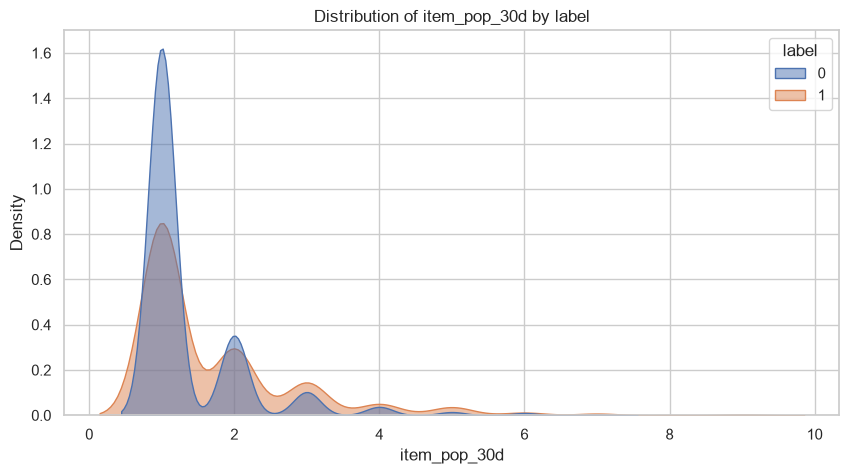

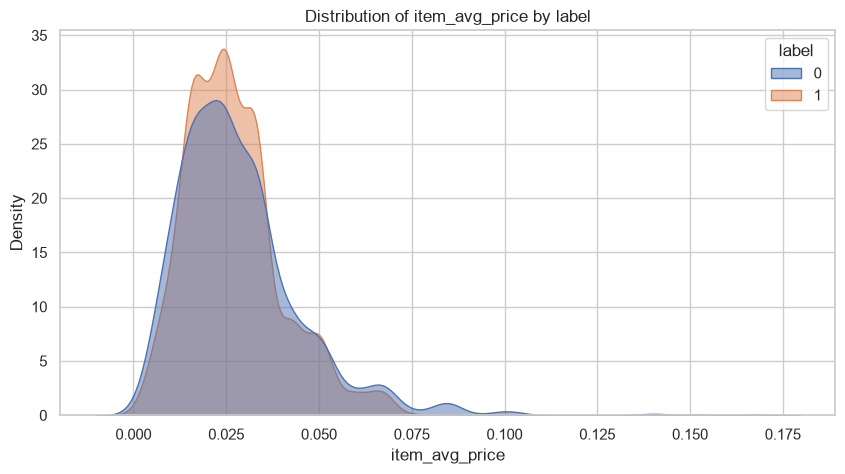

C:\Users\rahul\AppData\Local\Temp\ipykernel_11928\1945440471.py:10: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=df, x=feature, hue=target, common_norm=False, fill=True, alpha=0.5)


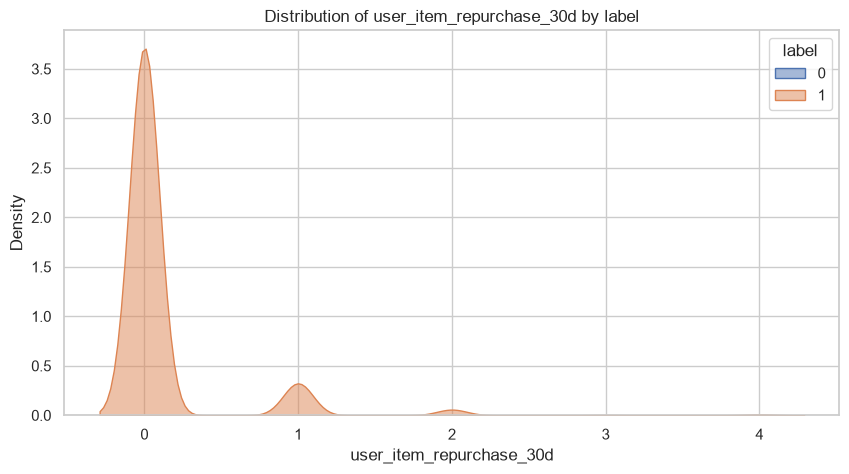

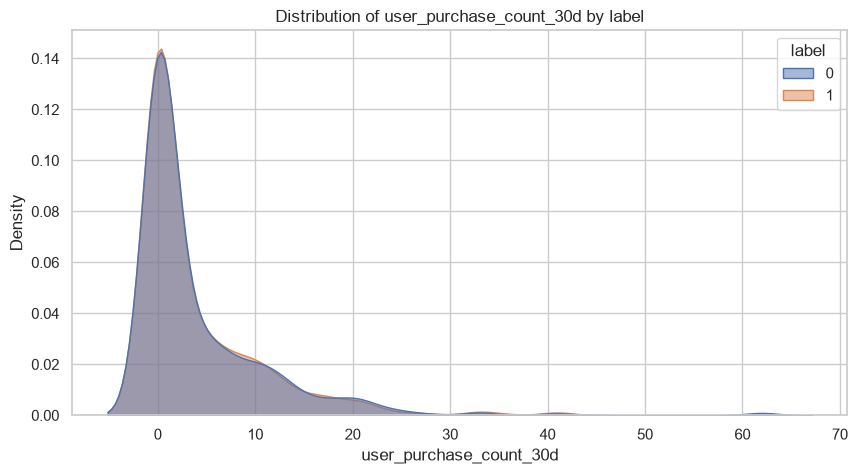

In [ ]:
def plot_feature_vs_target(df: pd.DataFrame, feature: str, target: str = 'label'):
    """
    Plot the distribution of a feature grouped by the target variable.
    """
    if feature not in df.columns:
        print(f"Feature {feature} not found in DataFrame.")
        return
        
    plt.figure(figsize=(10, 5))
    sns.kdeplot(data=df, x=feature, hue=target, common_norm=False, fill=True, alpha=0.5)
    plt.title(f'Distribution of {feature} by {target}')
    plt.xlabel(feature)
    plt.ylabel('Density')
    plt.show()

# Example features to analyze
num_features_to_analyze = [
    'item_pop_30d', 
    'item_avg_price', 
    'user_item_repurchase_30d', 
    'user_purchase_count_30d'
]


for feat in num_features_to_analyze:
    plot_feature_vs_target(df, feat)

## 5. Hypothesis Testing (Feature vs. Target)

To statistically validate the relationships observed in the EDA, we perform hypothesis testing.

### **Numeric Features vs. Target** 

Added a function test_numeric_vs_target that uses the Mann-Whitney U Test. Since the target is binary (label 0 vs 1) and features like counts/popularity are highly skewed (violating the normality assumption of a standard t-test), the Mann-Whitney U test is the most appropriate non-parametric alternative.

In [ ]:
from scipy.stats import mannwhitneyu, chi2_contingency

def test_numeric_vs_target(df: pd.DataFrame, feature: str, target: str = 'label'):
    """
    Perform Mann-Whitney U test for a numeric feature against a binary target.
    Null Hypothesis (H0): The distribution of the feature is the same across both target groups.
    """
    group0 = df[df[target] == 0][feature].dropna()
    group1 = df[df[target] == 1][feature].dropna()

    
    
    if len(group0) == 0 or len(group1) == 0:
        print(f"Not enough data to test {feature}")
        return
        
    stat, p_value = mannwhitneyu(group0, group1, alternative='two-sided')
    
    print(f"--- Mann-Whitney U Test for '{feature}' vs '{target}' ---")
    print(f"U-Statistic: {stat:.4f}, p-value: {p_value:.4e}")
    if p_value < 0.05:
        print("Conclusion: Reject H0. There is a statistically significant difference between the groups.\n")
    else:
        print("Conclusion: Fail to reject H0. No statistically significant difference observed.\n")



# Run tests on example features
print("Numeric Feature Tests:")
for feat in num_features_to_analyze:
    test_numeric_vs_target(df, feat)



Numeric Feature Tests:
--- Mann-Whitney U Test for 'item_pop_30d' vs 'label' ---
U-Statistic: 807315.5000, p-value: 5.1588e-20
Conclusion: Reject H0. There is a statistically significant difference between the groups.

--- Mann-Whitney U Test for 'item_avg_price' vs 'label' ---
U-Statistic: 979766.0000, p-value: 5.0902e-01
Conclusion: Fail to reject H0. No statistically significant difference observed.

--- Mann-Whitney U Test for 'user_item_repurchase_30d' vs 'label' ---
U-Statistic: 873413.0000, p-value: 1.5762e-34
Conclusion: Reject H0. There is a statistically significant difference between the groups.

--- Mann-Whitney U Test for 'user_purchase_count_30d' vs 'label' ---
U-Statistic: 973427.5000, p-value: 6.9651e-01
Conclusion: Fail to reject H0. No statistically significant difference observed.



### **Categorical Features vs. Target** 

We use the **Chi-Square Test of Independence** to determine if there is a significant association between a categorical feature and the target.

In [ ]:
def test_categorical_vs_target(df: pd.DataFrame, feature: str, target: str = 'label'):
    """
    Perform Chi-Square Test of Independence for a categorical feature against the target.
    Null Hypothesis (H0): The feature and the target are independent.
    """
    contingency_table = pd.crosstab(df[feature], df[target])
    
    if contingency_table.empty or contingency_table.size == 0:
        print(f"Not enough data to test {feature}")
        return
        
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)
    
    print(f"--- Chi-Square Test for '{feature}' vs '{target}' ---")
    print(f"Chi2-Statistic: {chi2:.4f}, p-value: {p_value:.4e}, Degrees of Freedom: {dof}")
    
    # Check assumption: expected frequencies >= 5
    if (expected < 5).sum() > 0:
        print("Warning: Some expected frequencies are less than 5. Consider grouping categories or using Fisher's Exact Test.")
        
    if p_value < 0.05:
        print("Conclusion: Reject H0. There is a statistically significant association between the feature and the target.\n")
    else:
        print("Conclusion: Fail to reject H0. No statistically significant association observed.\n")

cat_features_to_analyze = [
    'item_category',
    'item_color',
    'product_type_name',
    'department_name',
    'user_category_pref_1y_rank1',
    'user_category_pref_1y_rank2',
]

print("Categorical Feature Tests:")
for feat in cat_features_to_analyze:
    test_categorical_vs_target(df, feat)

Categorical Feature Tests:
--- Chi-Square Test for 'item_category' vs 'label' ---
Chi2-Statistic: 106.1300, p-value: 9.9191e-14, Degrees of Freedom: 20
Conclusion: Reject H0. There is a statistically significant association between the feature and the target.

--- Chi-Square Test for 'item_color' vs 'label' ---
Chi2-Statistic: 100.8431, p-value: 1.5097e-06, Degrees of Freedom: 43
Conclusion: Reject H0. There is a statistically significant association between the feature and the target.

--- Chi-Square Test for 'product_type_name' vs 'label' ---
Chi2-Statistic: 151.9511, p-value: 9.9186e-09, Degrees of Freedom: 66
Conclusion: Reject H0. There is a statistically significant association between the feature and the target.

--- Chi-Square Test for 'department_name' vs 'label' ---
Chi2-Statistic: 310.8377, p-value: 4.9232e-18, Degrees of Freedom: 124
Conclusion: Reject H0. There is a statistically significant association between the feature and the target.

--- Chi-Square Test for 'user_cat

In [19]:
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
print("Categorical columns:", cat_cols)

Categorical columns: ['customer_id', 'article_id', 'FN', 'Active', 'club_member_status', 'fashion_news_frequency', 'postal_code', 'product_code', 'prod_name', 'product_type_name', 'product_group_name', 'graphical_appearance_name', 'colour_group_code', 'perceived_colour_value_name', 'perceived_colour_master_name', 'department_name', 'index_code', 'index_name', 'index_group_name', 'section_name', 'detail_desc', 'item_category', 'item_color', 'first_sold_date', 'user_category_pref_1y_rank1', 'user_category_pref_1y_rank2', 'user_category_pref_1y_rank3', 'user_color_pref_1y_rank1', 'user_color_pref_1y_rank2', 'snap_date']


C:\Users\rahul\AppData\Local\Temp\ipykernel_11928\581676910.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()


## 6. Feature Selection: Correlation Matrix

We compute the correlation matrix to identify highly correlated (redundant) features and to see which features have the highest linear correlation with the target variable.

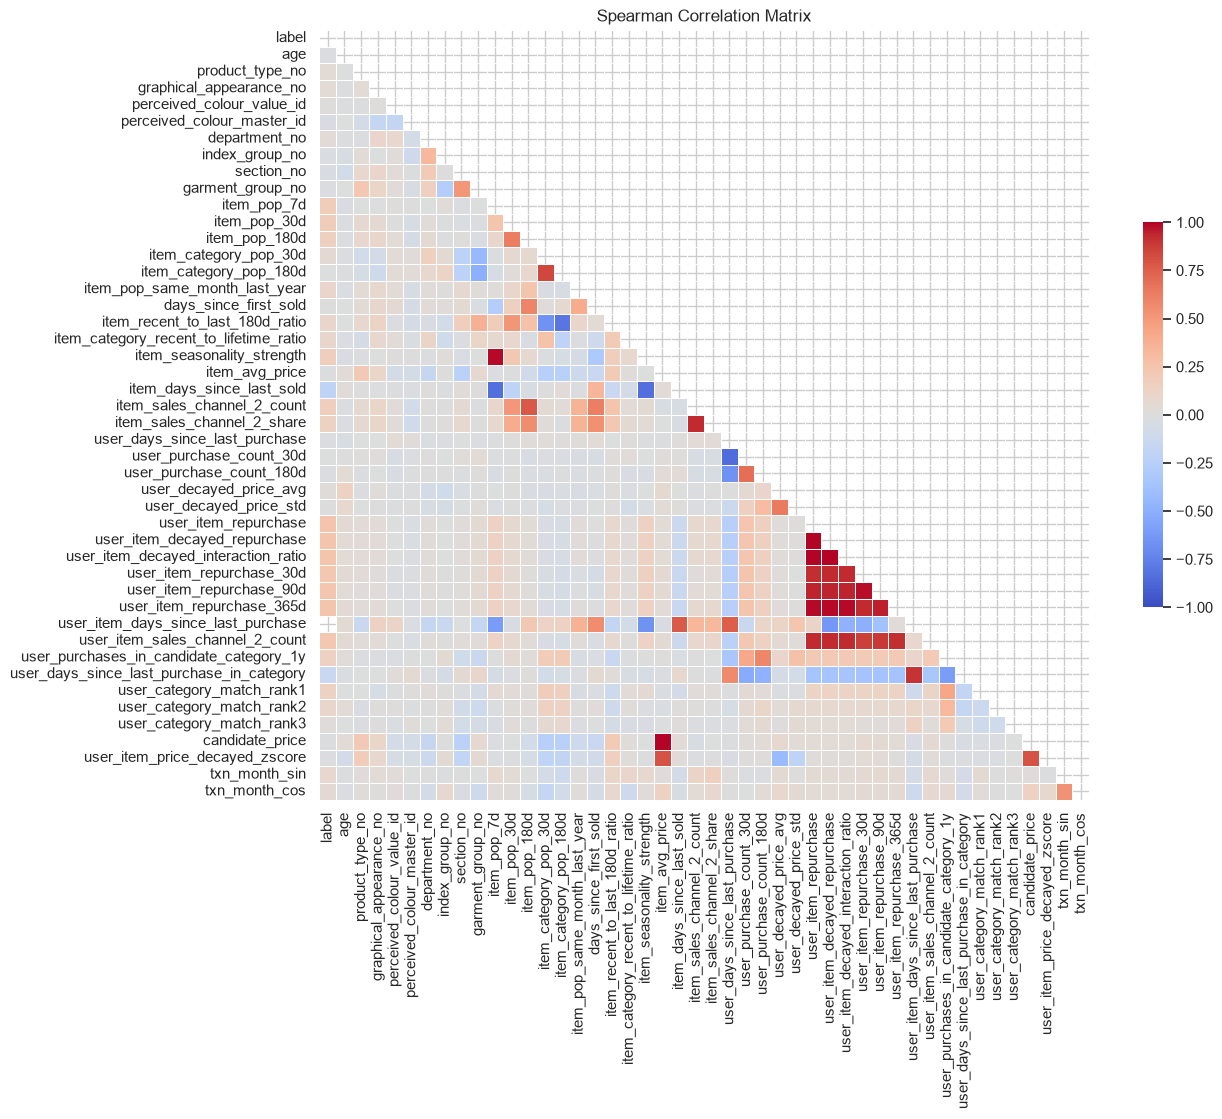


Top correlations with label:
label                                  1.000000
user_item_repurchase                   0.252145
user_item_decayed_repurchase           0.252094
user_item_decayed_interaction_ratio    0.252093
user_item_repurchase_365d              0.249367
user_item_repurchase_90d               0.237028
user_item_sales_channel_2_count        0.233115
user_item_repurchase_30d               0.232142
item_pop_7d                            0.179297
item_pop_30d                           0.173524
Name: label, dtype: float64

Bottom correlations with target:
perceived_colour_master_id                  -0.031411
section_no                                  -0.033667
user_days_since_last_purchase_in_category   -0.143385
item_days_since_last_sold                   -0.207569
user_item_days_since_last_purchase                NaN
Name: label, dtype: float64


In [ ]:
def plot_correlation_matrix(df: pd.DataFrame, target: str = 'label'):
    """
    Plot a correlation matrix for numeric features.
    """
    # Select only numeric columns
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    
    # Drop ID columns if present
    cols_to_exclude = ['customer_id', 'article_id']
    numeric_cols = [c for c in numeric_cols if c not in cols_to_exclude]
    
    if not numeric_cols:
        print("No numeric columns found for correlation matrix.")
        return
        
    # Calculate Spearman correlation (better for monotonic relationships and tree models)
    corr = df[numeric_cols].corr(method='spearman')
    
    # Plot heatmap
    plt.figure(figsize=(14, 10))
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=False, cmap='coolwarm', vmin=-1, vmax=1, center=0,
                square=True, linewidths=.5, cbar_kws={"shrink": .5})
    plt.title('Spearman Correlation Matrix')
    plt.show()
    
    # Show top correlations with target
    if target in corr.columns:
        print(f"\nTop correlations with {target}:")
        target_corr = corr[target].sort_values(ascending=False)
        print(target_corr.head(10))
        print("\nBottom correlations with target:")
        print(target_corr.tail(5))

plot_correlation_matrix(df)

## 7. Baseline Model & Feature Importance (TODO)

To properly select features, we typically train a quick baseline model (like Random Forest or XGBoost) and analyze the Feature Importance and SHAP values. This helps us identify non-linear relationships and interactions that simple correlation might miss.

**TODO for future:**
- Train a quick baseline XGBoost model.
- Plot XGBoost feature importance.
- Calculate and plot SHAP values.
- Drop features with near-zero variance or no predictive power to finalize the model input schema.

In [ ]:
# TODO: Implement baseline model training and SHAP analysis
# The code below is commented out for future implementation.


from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
import shap

def train_baseline_and_analyze(df: pd.DataFrame, target: str = 'label'):
    # 1. Prepare data
    # Exclude IDs, dates, and the target itself
    exclude_cols = ['customer_id', 'article_id', 'snap_date', target]
    features = [c for c in df.columns if c not in exclude_cols]
    
    # Handle categorical features if any
    X = df[features].copy()
    for col in X.select_dtypes(include=['object', 'category']).columns:
        X[col] = X[col].astype('category')
        
    y = df[target]
    
    # Split data
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    
    # 2. Train baseline XGBoost
    print("Training baseline XGBoost model...")
    # Calculate scale_pos_weight for imbalanced dataset
    pos_weight = (len(y_train) - sum(y_train)) / sum(y_train) if sum(y_train) > 0 else 1
    
    model = XGBClassifier(
        n_estimators=100,
        max_depth=4,
        learning_rate=0.1,
        scale_pos_weight=pos_weight,
        enable_categorical=True,
        random_state=42,
        n_jobs=-1
    )
    
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=10
    )
    
    # 3. Plot built-in feature importance
    plt.figure(figsize=(10, 8))
    importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=True)
    importances.tail(20).plot(kind='barh')
    plt.title('Top 20 XGBoost Feature Importances')
    plt.show()
    
    # 4. SHAP analysis
    print("Calculating SHAP values...")
    explainer = shap.TreeExplainer(model)
    # Use a sample for faster SHAP calculation
    X_sample = X_val.sample(n=min(1000, len(X_val)), random_state=42)
    shap_values = explainer.shap_values(X_sample)
    
    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values, X_sample, show=False)
    plt.title('SHAP Summary Plot')
    plt.show()
    
    return model, importances

# Run the analysis
model, importances = train_baseline_and_analyze(df)

# 5. Drop low-variance / zero-importance features
features_to_drop = importances[importances == 0].index.tolist()
print(f"Features to drop: {features_to_drop}")
final_df = df.drop(columns=features_to_drop)

# print("Baseline model training and SHAP analysis skipped. See commented code for future implementation.")

Baseline model training and SHAP analysis skipped. See commented code for future implementation.
